# Diabetic Retinopathy Detection
**PS-5 | EfficientNetB3 + TensorFlow/Keras | Kaggle**

| Grade | Label |
|-------|-------|
| 0 | No DR |
| 1 | Mild |
| 2 | Moderate |
| 3 | Severe |
| 4 | Proliferative DR |

**Metric:** Quadratic Weighted Cohen Kappa Score

## 1. Imports

In [1]:
import os
os.environ['KERAS_HOME'] = '/kaggle/working'

import urllib.request
urllib.request.urlretrieve(
    'https://storage.googleapis.com/keras-applications/efficientnetb3_notop.h5',
    '/kaggle/working/efficientnetb3_notop.h5'
)
print("Weights downloaded!")

Weights downloaded!


In [2]:
!pip install -q kaggle

In [3]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.endswith(".csv"):
            print(os.path.join(root, f))

/kaggle/input/datasets/sovitrath/diabetic-retinopathy-224x224-2019-data/train.csv


In [4]:
import os, shutil, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import cohen_kappa_score, confusion_matrix, classification_report

print("TensorFlow:", tf.__version__)
print("GPU:", len(tf.config.list_physical_devices("GPU")) > 0)

2026-07-05 19:46:43.754379: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783280803.915315      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783280803.961803      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783280804.347451      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783280804.347482      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783280804.347485      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: True


## 2. Configuration

In [5]:
BASE      = "/kaggle/input/datasets/sovitrath/diabetic-retinopathy-224x224-2019-data"
TRAIN_CSV = os.path.join(BASE, "train.csv")
IMAGE_DIR = os.path.join(BASE, "colored_images")

WORK_DIR    = "/kaggle/working"
IMG_SIZE    = 224
BATCH_SIZE  = 64
EPOCHS      = 20
NUM_CLASSES = 5
LR          = 1e-4

# Class folder name → numeric label
CLASS_MAP = {"No_DR": 0, "Mild": 1, "Moderate": 2, "Severe": 3, "Proliferate_DR": 4}
CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]

print("Config ready.")

Config ready.


## 3. Load & Explore Data

In [6]:
df = pd.read_csv(TRAIN_CSV)
print(f"CSV shape: {df.shape}")
print(df["diagnosis"].value_counts().sort_index())
df.head(10)

CSV shape: (3662, 2)
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0
5,0083ee8054ee,4
6,0097f532ac9f,0
7,00a8624548a9,2
8,00b74780d31d,2
9,00cb6555d108,1


In [7]:
# Build a flat dataframe: full image path + label
records = []
for folder, label in CLASS_MAP.items():
    folder_path = os.path.join(IMAGE_DIR, folder)
    for fname in os.listdir(folder_path):
        if fname.endswith(".png"):
            records.append({"filepath": os.path.join(folder_path, fname), "label": label})

data = pd.DataFrame(records)
data["label_str"] = data["label"].astype(str)
print(f"Total images found: {len(data)}")
print(data["label"].value_counts().sort_index())

Total images found: 3662
label
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


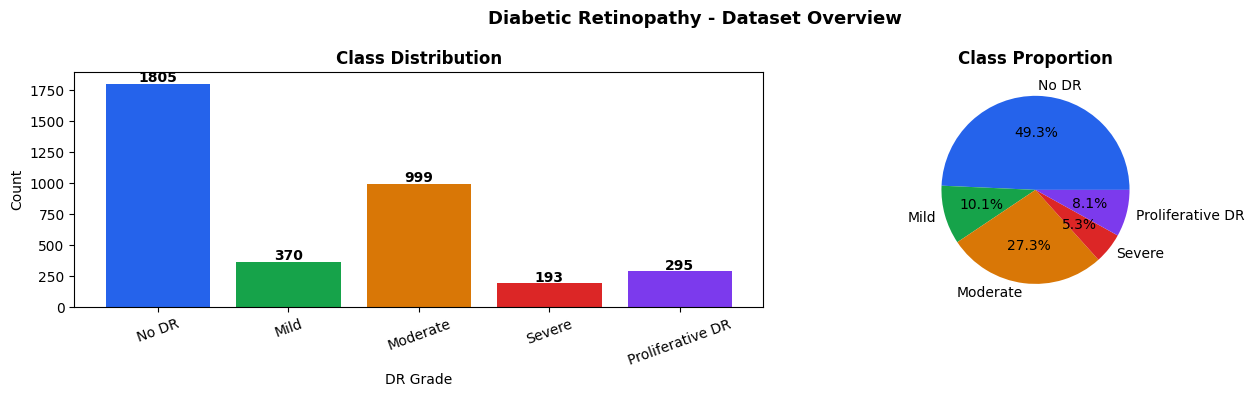

In [8]:
counts = data["label"].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(CLASS_NAMES, counts.values, color=["#2563EB","#16A34A","#D97706","#DC2626","#7C3AED"])
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_xlabel("DR Grade"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(counts.values):
    axes[0].text(i, v+10, str(v), ha="center", fontweight="bold")
axes[1].pie(counts.values, labels=CLASS_NAMES, autopct="%1.1f%%",
            colors=["#2563EB","#16A34A","#D97706","#DC2626","#7C3AED"])
axes[1].set_title("Class Proportion", fontweight="bold")
plt.suptitle("Diabetic Retinopathy - Dataset Overview", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## 4. Train / Validation Split

In [9]:
train_df, val_df = train_test_split(
    data, test_size=0.2, stratify=data["label"], random_state=42
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"Train: {len(train_df)} | Val: {len(val_df)}")

Train: 2929 | Val: 733


## 5. Data Generators

In [10]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1
)
val_gen = ImageDataGenerator(rescale=1./255)

train_loader = train_gen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label_str",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_loader = val_gen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label_str",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)
print("Class indices:", train_loader.class_indices)

Found 2929 validated image filenames belonging to 5 classes.
Found 733 validated image filenames belonging to 5 classes.
Class indices: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}


## 6. Build Model - EfficientNetB3

In [11]:
from tensorflow.keras.applications import MobileNetV2

def build_model(num_classes=5):
    base = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    for layer in base.layers[:-30]:
        layer.trainable = False
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs=base.input, outputs=output)

model = build_model(NUM_CLASSES)
print("Model built.")

I0000 00:00:1783280823.365807      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783280823.371528      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model built.


## 7. Class Weights & Compile

In [12]:
labels_arr = train_df["label"].values
weights    = compute_class_weight(class_weight="balanced", classes=np.arange(NUM_CLASSES), y=labels_arr)
class_weights = dict(enumerate(weights))
print("Class weights:", {k: round(v,3) for k,v in class_weights.items()})

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Class weights: {0: np.float64(0.406), 1: np.float64(1.979), 2: np.float64(0.733), 3: np.float64(3.804), 4: np.float64(2.482)}


## 8. Callbacks

In [13]:
callbacks = [
    ModelCheckpoint(
        "/kaggle/working/best_model.keras",
        monitor="val_accuracy", save_best_only=True, verbose=1
    ),
    EarlyStopping(
        monitor="val_loss", patience=5,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=3, min_lr=1e-7, verbose=1
    )
]
print("Callbacks ready.")

Callbacks ready.


## 9. Train

In [ ]:
history = model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20


I0000 00:00:1783280838.144723     136 service.cc:152] XLA service 0x7a3f7c215630 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783280838.144805     136 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1783280838.144811     136 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


## 10. Training Curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training Summary", fontsize=14, fontweight="bold")
axes[0].plot(history.history["loss"],     label="Train", color="#2563EB")
axes[0].plot(history.history["val_loss"], label="Val",   color="#DC2626")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history["accuracy"],     label="Train", color="#2563EB")
axes[1].plot(history.history["val_accuracy"], label="Val",   color="#DC2626")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Evaluate - Kappa Score

In [ ]:
val_loader.reset()
preds        = model.predict(val_loader, verbose=1)
pred_classes = np.argmax(preds, axis=1)

# val_loader class indices map strings to positions; remap to actual labels
idx_to_label = {v: int(k) for k, v in val_loader.class_indices.items()}
true_classes = np.array([idx_to_label[i] for i in val_loader.classes])
pred_classes = np.array([idx_to_label[i] for i in pred_classes])

kappa = cohen_kappa_score(true_classes, pred_classes, weights="quadratic")
print(f"Quadratic Weighted Kappa Score: {kappa:.4f}")
print()
print(classification_report(true_classes, pred_classes, target_names=CLASS_NAMES))

## 12. Confusion Matrix

In [ ]:
cm = confusion_matrix(true_classes, pred_classes)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(5)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticks(range(5)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix", fontweight="bold")
for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i,j], ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Generate submission.csv

In [ ]:
# Using validation set as submission (replace with test set if available)
submission = pd.DataFrame({
    "id_code"   : val_df["filepath"].apply(lambda x: os.path.splitext(os.path.basename(x))[0]),
    "diagnosis" : pred_classes
})
submission.to_csv("/kaggle/working/submission.csv", index=False)
print(f"submission.csv saved — {len(submission)} rows")
submission.head(10)

## 14. Sample Predictions

In [ ]:
import pandas as pd
import numpy as np

submission = pd.DataFrame({
    "id_code"   : val_df["filepath"].apply(lambda x: os.path.splitext(os.path.basename(x))[0]),
    "diagnosis" : pred_classes
})
submission.to_csv("/kaggle/working/submission.csv", index=False)
print(f"Done — {len(submission)} rows")
print(submission.head())

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle("Sample Predictions", fontsize=14, fontweight="bold")

for i, ax in enumerate(axes.flat):
    row      = val_df.iloc[i]
    img      = cv2.imread(row["filepath"])
    img      = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    true_lbl = CLASS_NAMES[int(row["label"])]
    pred_lbl = CLASS_NAMES[pred_classes[i]]
    color    = "green" if true_lbl == pred_lbl else "red"
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl}", color=color, fontsize=8)

plt.tight_layout()
plt.savefig("/kaggle/working/sample_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Summary

| Item | Detail |
|------|--------|
| Model | EfficientNetB3 (pretrained ImageNet) |
| Framework | TensorFlow / Keras |
| Classes | 5 (No DR → Proliferative DR) |
| Loss | Categorical Crossentropy + class weights |
| Optimizer | Adam (lr=1e-4) |
| Callbacks | ModelCheckpoint, EarlyStopping, ReduceLROnPlateau |
| Metric | Quadratic Weighted Kappa |
| Outputs | submission.csv, best_model.keras, training_curves.png |